# TTE classification rasters (COARSENED) mapped in ABoVE domain

coarsened during direct GEE download here:  `download_mosaic_GEE.ipynb`

Paul Montesano, PhD | Nov 2025

In [1]:
library(tidyverse)
library(sf)
library(ggspatial)
library(terra)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE

terra 1.7.78


Attaching package: ‘terra’


The following object is masked from ‘package:tidyr’:

    extract




In [2]:
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:terra’:

    area




In [3]:
library(RColorBrewer)
library(viridis)

Loading required package: viridisLite



In [4]:
OUTDIR = '/projects/my-public-bucket/tte_nwt_nfi_pft/paper_figs'

In [5]:
source('/projects/code/3dsi/boreal_map_functions.R')


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




[1] "MAAP"
[1] "MAAP"



Attaching package: ‘data.table’


The following object is masked from ‘package:terra’:

    shift


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:terra’:

    rescale


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [6]:
crs_canalb

[1] "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"

In [7]:
above_domain = st_read(above_domain_fn) %>% st_transform(crs = crs_canalb)

Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


In [8]:
crs_map = '+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-150 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs'

In [9]:
disp_win_wgs84 <- st_sfc(st_point(c(-132, 54)), st_point(c(-86, 73)), crs = 4326)
disp_win_trans <- st_transform(disp_win_wgs84, crs = crs_canalb)
disp_win_coord <- st_coordinates(disp_win_trans)

In [10]:
theme_custom = list(
      theme_minimal(),
          annotation_scale(location = "bl", style="ticks") ,
          annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
    )

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers
Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


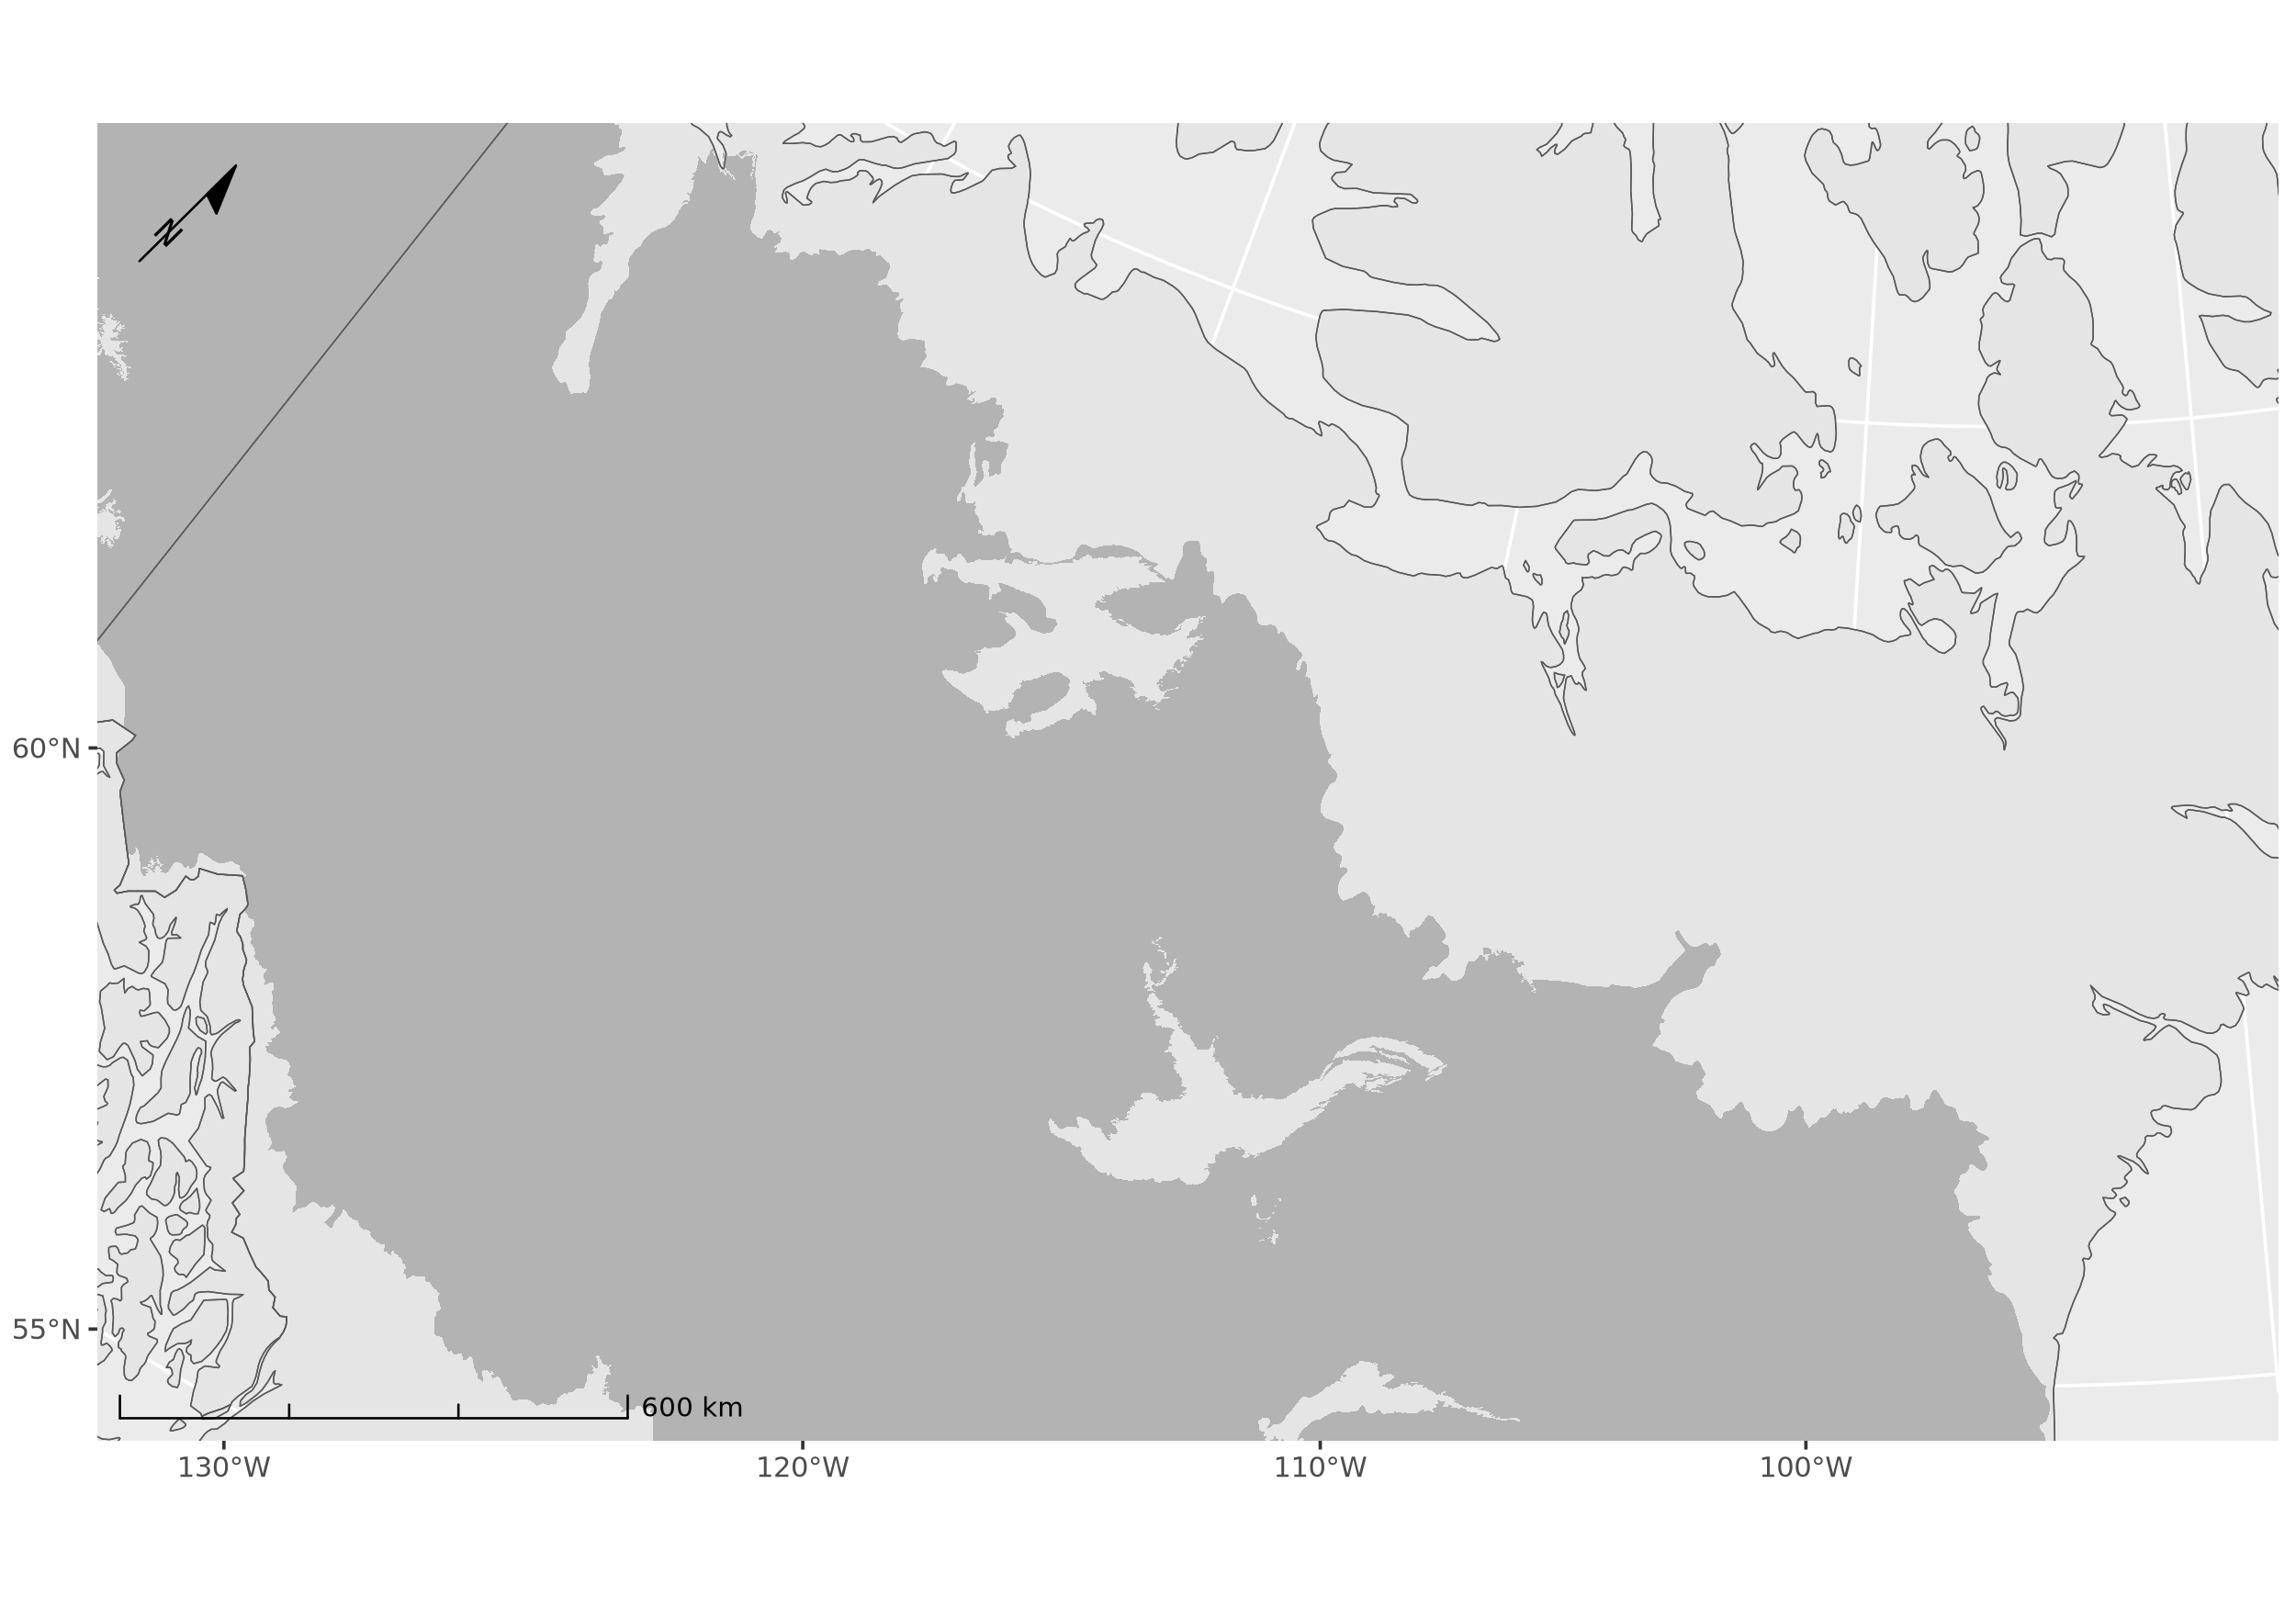

In [11]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 250)

map_list = list(
    annotation_scale(location = "bl", style="ticks") ,
    annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
    #, geom_sf(data = above_domain, fill=NA, linetype = "dotted", linewidth=0.75)
    )

map_tte_overview = do_map_above_boreal(ABOVE_DOMAIN = FALSE) + 
    #GET_CUSTOM_ABOVE_MAP() +
    #geom_sf(data=sample_n(lvis_footprints_trans,1000), aes(color=campaign, fill=campaign)) +
    #geom_sf(data=lvis_footprints_trans, aes(color=campaign, fill=campaign), linewidth=0.5) +
    scale_fill_brewer(palette = 'Set2', aesthetics = c("colour", "fill")) + 
    map_list +
    coord_sf(xlim = disp_win_coord[,'X'], ylim = disp_win_coord[,'Y'], crs = crs_canalb, expand = F)

map_tte_overview

In [12]:
hs_dem <-function(dem_r, crs_gcs, azimuth = 315, altitude = 60, return_df=TRUE){
  
  # Projection to GCS seems to need a flip
  #dem_r = flip(projectRaster(dem_r, crs=crs_gcs), direction='x')
  #dem_r = projectRaster(flip(dem_r, direction='y'), crs=crs_gcs) 
  dem_r = project(dem_r, crs_gcs, method='cubic') #, method='cubic') 
  
  slope <- terrain( dem_r, v='slope')
  aspect <- terrain( dem_r, v='aspect')

  # Calculate hillshade
  cat("Computing hillshade...\n")
  hs_file <- terra::shade(
      slope = slope, 
      aspect = aspect,
      angle = altitude,
      direction = azimuth,
      normalize = FALSE
    )

  # Breaks
  #b.hs <- seq(raster::cellStats(hs_file, "min"), raster::cellStats(hs_file, "max"), length.out=100)
  b.hs <- seq(terra::global(hs_file, "min", na.rm=TRUE)$min, terra::global(hs_file, "max", na.rm=TRUE)$max, length.out=100)
  
  if(return_df){
      #--- converting to a data.frame ---#
      hs_file <- as.data.frame(hs_file, xy = TRUE) %>%
        na.omit()
  }      
  
  return(list(hs_file, b.hs))
  #return(hs_file)
}

ggplot_hillshade <- function(dem_r, crs_gcs){
  
  out_hs_list = hs_dem(dem_r, crs_gcs)
  hs_df = out_hs_list[[1]]
  b.hs = out_hs_list[[2]]
  names(hs_df) <- c('x','y','hs')
  p = ggplot() +
    geom_raster(data = hs_df, aes(x = x, y = y, alpha = 1-hs),  show.legend=FALSE) +
    scale_fill_gradientn(colours=grey(1:100/100), breaks=b.hs, guide="none")#+
    #theme_map_axis
  
  return(p)
}

In [14]:
raster_read_proj_convert <- function(fn, to_crs="EPSG:4326", BOREAL_MAP=TRUE, LYR=NA){
    
    raster_proj <- rast(fn)    
    r <- project(raster_proj, to_crs , method='cubic' )
    r[is.infinite(r), 'class'] <- NA
    # Convert raster to data frame
    r_df <- as.data.frame(r, xy = TRUE)
    
    if(BOREAL_MAP){
        names(r_df)[names(r_df) == 'lyr1'] <- 'prediction mean'
        names(r_df)[names(r_df) == 'sd']   <- 'prediction standard deviation'
        }
    if(!is.na(LYR)){
        names(r_df) <- c('x','y', LYR)
        }
    return (r_df)
    }

# Create the named classification vector
tte_classes <- c(
  "1" = "Sparse & Abrupt",
  "2" = "Sparse & Diffuse-rapid", 
  "3" = "Sparse & Diffuse-gradual    ",
  "4" = "Sparse & Uniform",
  "5" = "Open & Uniform",
  "6" = "Open & Diffuse-gradual    ",
  "7" = "Open & Diffuse-rapid", 
  "8" = "Open & Abrupt",
  "9" = "Intermediate & Closed    ",
  "10" = "Non-forest edge (dry)",
  "11" = "Non-forest edge (wet)"
)

# Create the color palette vector (matching your original colors)
tte_colors <- c(
  "1" = "#5255a3",   # Sparse & Abrupt
  "2" = "#1796a3",   # Sparse & Diffuse-rapid
  "3" = "#fdbf6f",   # Sparse & Diffuse-gradual
  "4" = "#ff7f00",   # Sparse & Uniform
  "5" = "#ffffbf",   # Open & Uniform
  "6" = "#d9ef8b",   # Open & Diffuse-gradual
  "7" = "#91cf60",   # Open & Diffuse-rapid
  "8" = "#1a9850",   # Open & Abrupt
  "9" = "#c4c4c4",   # Intermediate & Closed
  "10" = "#ff0000",  # Non-forest edge (dry)
  "11" = "#0000ff"   # Non-forest edge (wet)
)

In [ ]:
# r_df = raster_read_proj_convert('/projects/my-public-bucket/local_output/TTEmap_3000/TTEmap_3000_classification_mosaic.tif', 
#                                 to_crs=crs_canalb, BOREAL_MAP=FALSE, LYR='class') 
r_df = raster_read_proj_convert('/projects/my-public-bucket/DPS_tile_lists/TTE/download_gee_tiles_v1/tte_montesano_2010_30m/tte_classification_band4_4809tiles_0p010000.tif', 
                                to_crs=crs_canalb, BOREAL_MAP=FALSE, LYR='class')

In [ ]:
r_df$class = round(r_df$class,0)
# Convert class values to factors with proper labels
r_df$class <- factor(r_df$class)
# Convert class values to factors with proper labels
r_df$class_factor <- factor(r_df$class, 
                           levels = names(tte_classes),
                           labels = tte_classes)



head(r_df)

In [ ]:
# MERIT DEM 3000m
dem_r = rast('/projects/my-public-bucket/local_output/MERIT_DEM_3000/MERIT_DEM_3000_mosaic.tif')
hs_df = hs_dem(dem_r, crs_canalb)[[1]]

In [ ]:
options(repr.plot.width = 11, repr.plot.height = 7, repr.plot.res = 300)


# Create the plot
map_tte_overview_hillshade = map_tte_overview + 
    #geom_raster(data = hs_df, mapping = aes(x = x, y = y, alpha = hillshade-0.1),  show.legend=FALSE) +
    geom_raster(data = r_df, mapping = aes(x = x, y = y, fill = class)) +
    scale_fill_manual(values = tte_colors, labels = tte_classes,
                   name = "TTE forest structure pattern class",
                   na.value = "transparent") +
    guides(fill = guide_legend(
        nrow = 6,          # 2 rows to accommodate 11 classes in ~6 columns each
        ncol = 2,          # 6 columns
        byrow = FALSE,      # Fill by rows first
        title.position = "top",
        title.hjust = 0.5,
        label.position = "right",
        #override.aes = list(size = 3)  # Make legend keys more visible
    )) +
    theme(
        legend.position = c(0.98, 0.97),
        legend.justification = c("right", "top"),
        legend.direction = "horizontal",
        legend.title = element_text(size = 12
                                    #, face = "bold"
                                    , hjust = 0.5),
        legend.text = element_text(size = 8),
        #legend.key.size = unit(0.35, "cm"),
        legend.key.width = unit(0.35, "cm"),
        legend.key.height = unit(0.35, "cm"),
        legend.box = "horizontal",
        # # Increase spacing between legend items
        # legend.spacing.x = unit(5.75, "cm"),  # Horizontal spacing between items
        # legend.spacing.y = unit(0.01, "cm"),  # Vertical spacing between rows
        # Add overall margin to the legend
        #legend.margin = margin(t = 5, r = 5, b = 5, l = 5)
    )

map_tte_overview_hillshade

In [370]:
OUTDIR

[1] "/projects/my-public-bucket/tte_nwt_nfi_pft/paper_figs"

In [390]:
ggsave(paste0(OUTDIR, "/map_tte_class_hillshade_overview.png"), map_tte_overview_hillshade, width = 11, height = 7, dpi = 250, bg='white', create.dir = TRUE)

✔ Created directory: /projects/my-public-bucket/tte_nwt_nfi_pft/paper_figs.

Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
